# 60/40 vs. Diversified Portfolio Risk and Return Analysis by Kira Novitchkova-Burbank

Start with installing yfinance. Note: upgrade yfinance is a more updated version of yfinance.

In [43]:
!pip install -q --upgrade yfinance

## Is the 60/40 portfolio still enough?

The 60/40 portfolio, with 60% in stocks and 40% in bonds, has been a standard investing approach for decades. The idea is that bonds cushion the portfolio when stocks fall. In 2022, though, stocks and bonds dropped at the same time, which raised questions about whether 60/40 still works.

This project compares a classic 60/40 portfolio against a more diversified mix that adds international stocks, real estate, gold, and cash. It uses daily prices for six ETFs from 2015 to 2026:

**SPY** (State Street SPDR S&P 500 ETF Trust): _US stocks_. The world's oldest and largest ETF, acting as the absolute benchmark for giant U.S. companies.

**VXUS** (Vanguard Total International Stock ETF): _International stocks_. Exposure to thousands of non-U.S. companies across developed and emerging markets.

**AGG** (iShares Core U.S. Aggregate Bond ETF): _US bonds_. The default powerhouse for broad, investment-grade U.S. bonds.

**VNQ** (Vanguard Real Estate ETF): _Real Estate_. The most heavily traded vehicle tracking domestic Real Estate Investment Trusts (REITs).

**GLD** (SPDR Gold Shares): _Gold_. The dominant, multi-billion dollar physically-backed gold fund used as a global safety haven.

**BIL** (SPDR Bloomberg 1-3 Month T-Bill ETF): _cash/T-bills_. A high-liquidity capital preservation tool tracking ultra-short U.S. government debt.

###The steps completed:

1. Downloaded adjusted closing prices with yfinance

2. Stored the data in a SQLite database

3. Calculated daily returns in SQL

4. Built a function for six risk and return metrics:

- Total return

- Annualized return

- Volatility

- Sharpe ratio

- Max drawdown

- Value at Risk

5. Built both portfolios and compared them over the full period

6. Stress tested both portfolios during the 2020 Covid crash and the 2022 rate hikes

7. Plotted growth and drawdown charts to compare the portfolios over time


## 1. Downloading adjusted closing prices with yfinance

In [44]:
import yfinance as yf
import pandas as pd

# The six ETFs, one per asset class
tickers = ["SPY", "VXUS", "AGG", "VNQ", "GLD", "BIL"]

# Pull daily prices from 2015 to the day I was working on this
data = yf.download(tickers, start="2015-01-01", end="2026-09-28", auto_adjust=True, threads=False) #threads=False because I want to download each ticker individually. Downloading them all at once caused a "database is locked" error that stopped VNQ from downloading.

[*********************100%***********************]  6 of 6 completed


Viewing the data.

In [45]:
data

Price           Close                                                \
Ticker            AGG        BIL         GLD         SPY        VNQ   
Date                                                                  
2015-01-02  79.529236  72.826614  114.080002  169.267502  51.642838   
2015-01-05  79.702095  72.842590  115.800003  166.210617  51.925488   
2015-01-06  79.903755  72.826614  117.120003  164.645096  52.440529   
2015-01-07  79.889320  72.826614  116.430000  166.696777  53.244522   
2015-01-08  79.766907  72.826614  115.940002  169.654724  53.445492   
...               ...        ...         ...         ...        ...   
2026-09-21  95.870102  91.307205  398.380005  773.500000  93.003365   
2026-09-22  95.909958  91.307205  400.070007  773.380005  92.815002   
2026-09-23  95.072929  91.327141  392.880005  767.809998  91.449997   
2026-09-24  94.614548  91.317177  391.690002  767.179993  91.169998   
2026-09-25  94.783951  91.357063  393.410004  771.349976  90.989998   

Price                       High                                     ...  \
Ticker           VXUS        AGG        BIL         GLD         SPY  ...   
Date                                                                 ...   
2015-01-02  34.354374  79.579648  72.842543  114.800003  170.462264  ...   
2015-01-05  33.599010  79.766914  72.842590  116.000000  168.394124  ...   
2015-01-06  33.342472  80.191828  72.842543  117.500000  167.034595  ...   
2015-01-07  33.734417  79.968540  72.842543  116.879997  167.034607  ...   
2015-01-08  34.161957  79.824517  72.842543  116.870003  169.868963  ...   
...               ...        ...        ...         ...         ...  ...   
2026-09-21  87.150002  95.899995  91.307205  400.239990  774.890015  ...   
2026-09-22  87.489998  95.969743  91.317179  400.779999  775.140015  ...   
2026-09-23  85.919998  95.750520  91.327141  395.500000  773.049988  ...   
2026-09-24  85.589996  95.192500  91.337116  393.070007  768.950012  ...   
2026-09-25  86.349998  94.833770  91.357063  394.220001  772.280029  ...   

Price             Open                                      Volume            \
Ticker             GLD         SPY        VNQ       VXUS       AGG       BIL   
Date                                                                           
2015-01-02  112.489998  170.050280  51.316220  34.447013   2090200    341000   
2015-01-05  114.779999  168.229334  51.504658  34.040821   3446200   2518350   
2015-01-06  116.220001  166.515492  51.975732  33.641762   3688100    541250   
2015-01-07  116.470001  165.963447  52.641541  33.648906   3984400    153800   
2015-01-08  116.449997  168.097428  53.608801  33.990935   2212200    236450   
...                ...         ...        ...        ...       ...       ...   
2026-09-21  400.170013  766.250000  92.468007  86.870003   9197400   9437800   
2026-09-22  397.070007  774.030029  93.102510  87.150002   7162700  14463700   
2026-09-23  395.329987  772.789978  92.080002  86.680000  17281500  10056200   
2026-09-24  391.959991  764.070007  91.790001  85.699997  10688500  11046400   
2026-09-25  392.209991  768.780029  91.550003  86.059998  15486800   7758000   

Price                                              
Ticker           GLD        SPY      VNQ     VXUS  
Date                                               
2015-01-02   7109600  121465900  5570500  1149300  
2015-01-05   8177400  169632600  6073700   688500  
2015-01-06  11238300  209151400  7577100   570000  
2015-01-07   6434200  125346700  6920700   490000  
2015-01-08   7033700  147217800  5255000   319300  
...              ...        ...      ...      ...  
2026-09-21   6411000   50484700  3018100  5051000  
2026-09-22   6519900   34802300  2955100  6760700  
2026-09-23   7547000   54931700  5415800  6194800  
2026-09-24   6710200   43983700  5787500  5628700  
2026-09-25   7701100   36666700  6148800  4235200  

[2950 rows x 30 columns]

Keeping only the adjusted closing prices because this project looks at performance over months and years, not within a single day. The close shows each ETF's value at the end of each trading day, and the adjustment includes dividends, so the prices reflect an investor's total return.

In [46]:
prices = data["Close"]

prices

Ticker,AGG,BIL,GLD,SPY,VNQ,VXUS
Date,,,,,,
2015-01-02,79.529236,72.826614,114.080002,169.267502,51.642838,34.354374
2015-01-05,79.702095,72.842590,115.800003,166.210617,51.925488,33.599010
2015-01-06,79.903755,72.826614,117.120003,164.645096,52.440529,33.342472
2015-01-07,79.889320,72.826614,116.430000,166.696777,53.244522,33.734417
2015-01-08,79.766907,72.826614,115.940002,169.654724,53.445492,34.161957
...,...,...,...,...,...,...
2026-09-21,95.870102,91.307205,398.380005,773.500000,93.003365,87.150002
2026-09-22,95.909958,91.307205,400.070007,773.380005,92.815002,87.489998
2026-09-23,95.072929,91.327141,392.880005,767.809998,91.449997,85.919998


### Exploring Data:

### - How many rows and columns are in the prices DataFrame?


In [47]:
prices = pd.DataFrame(prices)

dimensions = prices.shape
print(dimensions)

(2950, 6)


The prices DataFrame has 2950 rows and 6 columns, where each column is an ETF and each row is a trading day. The data starts on January 2, 2015 since January 1 is a market holiday.

Setting a fixed end date of September 28, 2026 so the results stay the same every time the notebook is run. Since yfinance doesn't include the end date and September 26 and 27 fall on a weekend, the last trading day in the data is Friday, September 25.

### - Are there any missing values?

In [48]:
missing_by_column = prices.isna().sum()
print(missing_by_column)

Ticker
AGG     0
BIL     0
GLD     0
SPY     0
VNQ     0
VXUS    0
dtype: int64


Checking for missing values in each ETF. All six have 0 missing values, so no cleaning is needed before calculating returns.

### - How much did each ETF grow from the first day to the last?

Finding the first and last rows.

In [49]:
first_row = prices.iloc[0]
last_row = prices.iloc[-1]
print("This is the first row:\n", first_row)
print("\nThis is the last row:\n", last_row)

This is the first row:
 Ticker
AGG      79.529236
BIL      72.826614
GLD     114.080002
SPY     169.267502
VNQ      51.642838
VXUS     34.354374
Name: 2015-01-02 00:00:00, dtype: float64

This is the last row:
 Ticker
AGG      94.783951
BIL      91.357063
GLD     393.410004
SPY     771.349976
VNQ      90.989998
VXUS     86.349998
Name: 2026-09-25 00:00:00, dtype: float64


Finding the **growth percentage** also known as calculating the total growth of each ETF from the first to the last trading day.

Easy explanation: **how much the price grew overall (percent)**

Note: growth percent = ((last row - first row)/first row) * 100

In [50]:
difference_in_dollars = last_row - first_row
growth_decimal = difference_in_dollars/first_row
growth_percent = growth_decimal*100
growth_percent

,0
Ticker,
AGG,19.181267
BIL,25.444611
GLD,244.854486
SPY,355.698801
VNQ,76.190934
VXUS,151.350814


The expected order, from least to most risk:
- Cash (BIL): safest, lowest expected return
- Bonds (AGG): a little riskier, so they should earn a bit more than cash
- Stocks (SPY): riskiest, highest expected return

SPY grew the most at about 356%, followed by GLD at 245% and VXUS at 151%. AGG grew the least at about 19%, which is interesting because it even trailed BIL at 25%. Bonds usually earn more than cash, so this is worth noting since bonds make up 40% of the classic 60/40 portfolio. It's something to look into later in the project.

## 2. Storing the data in a SQLite database

### Turning prices from wide format to long format

Reshaping the data so each row is one date and one ticker. Long format works better in SQL because I can group or partition by ticker instead of writing out each column separately.

In [51]:
prices_long = prices.reset_index().melt(id_vars="Date", var_name="ticker", value_name="close").rename(columns={"Date": "date"}) # note: changed Date from an index and to a column and changed Date to date for consistency


# Now, we need to check what the data type is for date. If it is not in YYYY-MM-DD format, we need to turn it into that.
print("Checking data types:\n", prices_long.dtypes)

prices_long['date'] = prices_long['date'].dt.strftime('%Y-%m-%d')

prices_long


Checking data types:
 date      datetime64[ns]
ticker            object
close            float64
dtype: object


,date,ticker,close
0,2015-01-02,AGG,79.529236
1,2015-01-05,AGG,79.702095
2,2015-01-06,AGG,79.903755
3,2015-01-07,AGG,79.889320
4,2015-01-08,AGG,79.766907
...,...,...,...
17695,2026-09-21,VXUS,87.150002
17696,2026-09-22,VXUS,87.489998
17697,2026-09-23,VXUS,85.919998
17698,2026-09-24,VXUS,85.589996



Checking that the reshape worked and no data was lost.

The wide data had 2,950 rows and 6 tickers, so the long version should have 2,950 x 6 = 17,700 rows. It should also have 3 columns: date, ticker, and close.

The shape matches, so the reshape looks correct.


### Now storing the data:

In [52]:
import sqlite3  # comes with Python, so nothing to install

# Connecting to the database. This creates portfolio.db the first time it runs
conn = sqlite3.connect("portfolio.db")

# Saving prices_long as a table called "prices"
# Using if_exists="replace" so I can rerun this cell without getting an error
# Using index=False because the pandas row numbers aren't part of the data
prices_long.to_sql("prices", conn, if_exists="replace", index=False)

17700

Finding the total rows. The answer should be 17700 as we have got from the previous cell and calculated earlier.

In [53]:
query = """SELECT COUNT(*) AS total_rows FROM prices"""
pd.read_sql(query, conn)

,total_rows
0,17700


Double checking the database.

In [54]:
# Checking that each ticker made it into the database correctly
query = """
    SELECT ticker,
           COUNT(ticker) AS ticker_rows,
           MIN(date) AS first_date,
           MAX(date) AS last_date
    FROM prices
    GROUP BY ticker
"""
# Running the query and returning the result as a DataFrame
pd.read_sql(query, conn)

,ticker,ticker_rows,first_date,last_date
0,AGG,2950,2015-01-02,2026-09-25
1,BIL,2950,2015-01-02,2026-09-25
2,GLD,2950,2015-01-02,2026-09-25
3,SPY,2950,2015-01-02,2026-09-25
4,VNQ,2950,2015-01-02,2026-09-25
5,VXUS,2950,2015-01-02,2026-09-25


Each ETF has 2,950 rows, the same as in wide format, and all six run from 2015-01-02 to 2026-09-25.

## 3. Calculating daily returns in SQL

Next, finding each day's previous closing price, which I need to calculate daily returns. To make sure it works, I'm checking a small sample first: one ETF over a short date range.

In [55]:
#note: LAG grabs the previous day's close for the same ticker
query = """
SELECT date, ticker, close,
       LAG(close) OVER (PARTITION BY ticker ORDER BY date) AS prev_close
FROM prices
WHERE ticker = 'SPY' AND date < '2015-01-10'
ORDER BY date
"""
pd.read_sql(query, conn)



,date,ticker,close,prev_close
0,2015-01-02,SPY,169.267502,NaN
1,2015-01-05,SPY,166.210617,169.267502
2,2015-01-06,SPY,164.645096,166.210617
3,2015-01-07,SPY,166.696777,164.645096
4,2015-01-08,SPY,169.654724,166.696777
5,2015-01-09,SPY,168.295227,169.654724


This looks correct. Each row's prev_close matches the close from the row above it. The first row's prev_close is empty because there's no earlier day to pull from.

Next, adding a **daily_return** column using (close / prev_close) - 1, then checking it on the same sample.

Note: daily returns is **how much the price changed in one day (decimal)**

In [56]:
query = """
WITH lagged AS (
    SELECT date, ticker, close,
           LAG(close) OVER (PARTITION BY ticker ORDER BY date) AS prev_close
    FROM prices
)
SELECT date, ticker, close, prev_close,
       close / prev_close - 1 AS daily_return
FROM lagged
WHERE ticker = 'SPY' AND date < '2015-01-10'
ORDER BY date
"""
pd.read_sql(query, conn)

,date,ticker,close,prev_close,daily_return
0,2015-01-02,SPY,169.267502,NaN,NaN
1,2015-01-05,SPY,166.210617,169.267502,-0.018059
2,2015-01-06,SPY,164.645096,166.210617,-0.009419
3,2015-01-07,SPY,166.696777,164.645096,0.012461
4,2015-01-08,SPY,169.654724,166.696777,0.017744
5,2015-01-09,SPY,168.295227,169.654724,-0.008013


Checking the first return by hand. On 2015-01-05, SPY went from 169.267517 to 166.210617, so (166.210617 / 169.267517) - 1 = -0.018060. This matches the daily_return column

Saving the daily returns as a new table called returns. This uses the same LAG() query as before, but without the SPY filter, so it covers all six ETFs and every date. It also drops each ticker's first day with WHERE prev_close IS NOT NULL, since there's no previous price to calculate a return from.

A few things that are new here:
- DROP TABLE IF EXISTS deletes the old table first, so I can rerun this cell without an error.
- conn.execute() is used instead of pd.read_sql() because this creates a table instead of returning results.
- conn.commit() saves the changes to the database.

In [57]:
conn.execute("DROP TABLE IF EXISTS returns")

query = """
CREATE TABLE returns AS
WITH lagged AS (
    SELECT date, ticker, close,
           LAG(close) OVER (PARTITION BY ticker ORDER BY date) AS prev_close
    FROM prices
)
SELECT date, ticker, close, prev_close,
       close / prev_close - 1 AS daily_return
FROM lagged
WHERE prev_close IS NOT NULL
"""
conn.execute(query)

conn.commit()

Checking that the first row was removed for each ETF. Each ticker should now have 2,949 rows instead of 2,950, and start on 2015-01-05 instead of 2015-01-02.

In [58]:
query = """
SELECT ticker, COUNT(*) AS num_rows, MIN(date) AS first_date, MAX(date) AS last_date
FROM returns
GROUP BY ticker
"""
pd.read_sql(query, conn)


,ticker,num_rows,first_date,last_date
0,AGG,2949,2015-01-05,2026-09-25
1,BIL,2949,2015-01-05,2026-09-25
2,GLD,2949,2015-01-05,2026-09-25
3,SPY,2949,2015-01-05,2026-09-25
4,VNQ,2949,2015-01-05,2026-09-25
5,VXUS,2949,2015-01-05,2026-09-25


## 4. Building a function for six risk and return metrics

Pulling the returns back into pandas and turning them into wide format again. Long format worked best for SQL, but wide format is easier for math in pandas, since each ETF gets its own column.

In [59]:
query = """
SELECT date, ticker, daily_return
FROM returns
"""

returns_long = pd.read_sql(query, conn)

In [60]:
returns_long['date']=pd.to_datetime(returns_long['date'])  # converting the text dates back to real dates so I can filter by date later

In [61]:
returns_wide = returns_long.pivot(index= "date", columns="ticker", values="daily_return") # turns returns into wide

Checking dimensions and for null values.

In [62]:
print("Checking dimensions of returns_wide:", returns_wide.shape, "\n")
print("Checking to see if any null values in returns_wide:\n", returns_wide.isna().sum())

Checking dimensions of returns_wide: (2949, 6) 

Checking to see if any null values in returns_wide:
 ticker
AGG     0
BIL     0
GLD     0
SPY     0
VNQ     0
VXUS    0
dtype: int64


returns_wide has 2,949 rows and 6 columns with no null values.

Turning each daily return into a **growth factor** by adding 1. A growth factor shows **what $1 becomes after that day (decimal)**, so a return of 0.01 (+1%) becomes 1.01, and -0.01 (-1%) becomes 0.99.

In [63]:
growth_factors = 1 + returns_wide  # what $1 becomes after each day
growth_factors.head()

ticker,AGG,BIL,GLD,SPY,VNQ,VXUS
date,,,,,,
2015-01-05,1.002174,1.000219,1.015077,0.981941,1.005473,0.978013
2015-01-06,1.002530,0.999781,1.011399,0.990581,1.009919,0.992365
2015-01-07,0.999819,1.000000,0.994109,1.012461,1.015332,1.011755
2015-01-08,0.998468,1.000000,0.995791,1.017744,1.003774,1.012674
2015-01-09,1.002437,1.000000,1.011385,0.991987,1.000470,0.995829


Finding the **total return** for each ETF by multiplying all the growth factors together, then subtracting 1 to turn it back into a return. _This should match the growth percentages from earlier._

It is basically **all the returns compounded (decimal)**.

In [64]:
total_return = growth_factors.prod() - 1  # compounding every day, then converting back to a return
total_return

,0
ticker,
AGG,0.191813
BIL,0.254446
GLD,2.448545
SPY,3.556988
VNQ,0.761909
VXUS,1.513508


Checking the total return values against the growth percentages from earlier.

Growth percentages:

AGG	19.181210

BIL	25.444526

GLD	244.854486

SPY	355.698842

VNQ	76.190973

VXUS	151.350953

The total returns are the decimal versions of these growth percentages.

For example, SPY's total return of 3.5570 × 100 should be 355.70%.

All six ETFs match, so the returns table was calculated correctly.

The ranking is the same as before as well, with SPY growing the most and AGG the least.

Now, I calculate the **annualized return** which is the **steady yearly growth rate (decimal)**.

It is calculated by: annualized return = (1 + total return) ^ (252 / number of days) - 1

In [65]:
annualized_return = (1 + total_return) ** (252 / len(returns_wide)) - 1
annualized_return

,0
ticker,
AGG,0.015108
BIL,0.019560
GLD,0.111584
SPY,0.138376
VNQ,0.049591
VXUS,0.081945


SPY had the highest annualized return at about 13.8% per year, and AGG had the lowest at about 1.5%. AGG still trailed BIL (about 2.0%) on a yearly basis too.

**Annualized volatility** measures **how much an investment's returns swing around, scaled to a full year (decimal)**.

annualized volatility = daily returns standard deviation * sqrt(252 traiding days)

In [66]:
import numpy as np

annualized_vol = returns_wide.std() * np.sqrt(252)
annualized_vol

,0
ticker,
AGG,0.051882
BIL,0.002621
GLD,0.162356
SPY,0.175411
VNQ,0.201731
VXUS,0.172412


VNQ was the riskiest at about 20.2% per year, and BIL was the least risky at about 0.3%. That makes sense for BIL, since T-bills are about as safe as it gets. VNQ stands out because it had the most risk but only about a 5.0% annualized return.

The **Sharpe ratio** shows the **extra return per unit of risk**. It compares each investment to cash, so first I need the **risk-free rate**, which is **what you'd earn with almost no risk**.

I'm using BIL's annualized return as the risk-free rate because it holds short-term T-bills, which are about as close to risk-free as investing gets. Like the other metrics, Sharpe is annualized.

Sharpe ratio = (annualized return − risk-free rate) / annualized volatility

In [67]:
rf = annualized_return["BIL"]  #risk-free rate

sharpe = (annualized_return - rf)/annualized_vol

sharpe = sharpe.sort_values(ascending=False)

sharpe.name = 'sharpe' #renaming the Series
sharpe.round(2)



,sharpe
ticker,
SPY,0.68
GLD,0.57
VXUS,0.36
VNQ,0.15
BIL,0.00
AGG,-0.09


SPY had the best Sharpe ratio at 0.68, with GLD close behind at 0.57. VNQ's extra risk barely paid off, with a Sharpe of only 0.15. AGG was negative at -0.09 because it earned less than cash. BIL's Sharpe is 0 by design, since its return is the risk-free rate as mentioned earlier.

Finding **Max Drawdown**:

To find max drawdown, I need to calculate wealth index, running peak, and drawdown.

**Wealth index** is **what $1 is worth each day**.  

wealth = (1 + each day's return), multiplied together up to that day


In [68]:
wealth=(1 + returns_wide).cumprod()

wealth.head()


ticker,AGG,BIL,GLD,SPY,VNQ,VXUS
date,,,,,,
2015-01-05,1.002174,1.000219,1.015077,0.981941,1.005473,0.978013
2015-01-06,1.004709,1.000000,1.026648,0.972692,1.015446,0.970545
2015-01-07,1.004528,1.000000,1.020600,0.984813,1.031015,0.981954
2015-01-08,1.002988,1.000000,1.016304,1.002288,1.034906,0.994399
2015-01-09,1.005433,1.000000,1.027875,0.994256,1.035393,0.990251


In [69]:
wealth.tail()

ticker,AGG,BIL,GLD,SPY,VNQ,VXUS
date,,,,,,
2026-09-21,1.205470,1.253761,3.492111,4.569690,1.800896,2.536795
2026-09-22,1.205971,1.253761,3.506925,4.568981,1.797248,2.546692
2026-09-23,1.195446,1.254035,3.443899,4.536074,1.770817,2.500992
2026-09-24,1.189683,1.253898,3.433468,4.532353,1.765395,2.491386
2026-09-25,1.191813,1.254446,3.448545,4.556988,1.761909,2.513508


The last row should equal 1 + total return. Total return is only the gain, while the wealth index is what you end up with, so it adds back the original $1. For example, SPY's total return was 3.557, so 1 dollar in SPY grew to 1 dollar + 3.557 = about 4.56 in wealth. AGG grew to only about 1.19.

Finding the **running peak** which is the **highest wealth so far**.

peak = max(wealth up to that day)

In [70]:
peak=wealth.cummax()  # gives a value for each day: the highest wealth so far as of that day.

(peak >= wealth).all().all()  # it confirms the peak is never below wealth on any day, for any ticker. (The first .all() checks each column, the second combines them into one answer.)

np.True_

Checking that the running peak works using SPY. The peak should stay the same when wealth drops and only move up when wealth hits a new high.

In [71]:
pd.DataFrame({'wealth': wealth['SPY'], 'peak': peak['SPY']}).head()

,wealth,peak
date,,
2015-01-05,0.981941,0.981941
2015-01-06,0.972692,0.981941
2015-01-07,0.984813,0.984813
2015-01-08,1.002288,1.002288
2015-01-09,0.994256,1.002288


Since everything looks good, I will calculate **drawdown** which is **how far down you are right now from your personal best**.

For example, if your best was 1.20 dollars and you're at 1.08 today, you're 10% below your best.

drawdown = (wealth/peak) -1



In [72]:
drawdown = wealth/peak - 1

drawdown.head()

ticker,AGG,BIL,GLD,SPY,VNQ,VXUS
date,,,,,,
2015-01-05,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2015-01-06,0.000000,-0.000219,0.000000,-0.009419,0.0,-0.007635
2015-01-07,-0.000181,-0.000219,-0.005891,0.000000,0.0,0.000000
2015-01-08,-0.001713,-0.000219,-0.010075,0.000000,0.0,0.000000
2015-01-09,0.000000,-0.000219,0.000000,-0.008013,0.0,-0.004171


Checking that drawdown lines up with wealth and peak using SPY.

In [73]:
pd.DataFrame({'wealth': wealth['SPY'], 'peak': peak['SPY'], 'drawdown': drawdown['SPY']}).head()

,wealth,peak,drawdown
date,,,
2015-01-05,0.981941,0.981941,0.000000
2015-01-06,0.972692,0.981941,-0.009419
2015-01-07,0.984813,0.984813,0.000000
2015-01-08,1.002288,1.002288,0.000000
2015-01-09,0.994256,1.002288,-0.008013


When wealth hits a new high, the peak moves up and drawdown is 0. When wealth drops, the peak stays the same and drawdown goes negative.

Now I will calculate **max drawdown**, which is the **worst drawdown over the whole period**, meaning the biggest drop from a high. I'm using .min() because drawdowns are negative, so the most negative number is the worst drop. Unlike the running peak, which gives a value for each day, this gives one number per ETF for the entire period, which is what I need to compare the ETFs.

In [74]:
max_drawdown = drawdown.min()

max_drawdown = max_drawdown.sort_values()  # worst to best
max_drawdown.name = 'max_drawdown'  # naming the series
max_drawdown.round(2)

,max_drawdown
ticker,
VNQ,-0.42
VXUS,-0.36
SPY,-0.34
GLD,-0.26
AGG,-0.18
BIL,-0.00


I would like to know when these drops occured. This gives the date of each ETF's lowest point.

In [75]:
drawdown.idxmin()

,0
ticker,
AGG,2022-10-20
BIL,2022-02-14
GLD,2026-07-16
SPY,2020-03-23
VNQ,2020-03-23
VXUS,2020-03-23


VNQ had the worst drop at about -42%, followed by VXUS (-36%) and SPY (-34%). All three hit bottom on March 23, 2020, during the Covid crash. AGG fell about 18%, which is a lot for bonds, with its low in October 2022 when rising interest rates pushed bond prices down. GLD's worst drop (-26%) was more recent, in July 2026. The Iran war pushed oil prices up, which raised inflation and expectations of rate hikes, and that pulled gold down. BIL barely dropped at all, which makes sense since T-bills are about as safe as it gets.

**VaR (95%)** shows **how much I might lose on a bad day**. If I line up all the daily returns from worst to best, VaR is the cutoff for the **worst 5% of days**. For example, with 100 days, it would be the 5th worst day. If that day was -2%, then on 1 in 20 days I'd lose 2% or more.

In [76]:
var_95 = returns_wide.quantile(0.05)

var_95 = var_95.sort_values()  # worst to best
var_95.name = 'var_95'  # naming the Series
var_95.round(4)

,var_95
ticker,
VNQ,-0.0187
SPY,-0.0165
VXUS,-0.0160
GLD,-0.0157
AGG,-0.0048
BIL,-0.0002


VNQ had the biggest bad-day loss at about -1.9%, which fits it being the riskiest ETF. SPY, VXUS, and GLD were close together at about -1.6%, even though their max drawdowns were quite different. So they had similar bad days, but SPY and VXUS fell much further over longer stretches. AGG lost about 0.5% on a bad day, and BIL barely moved.

**Building the function:**


In [77]:
def calc_metrics(returns, rf):
    total_return = (1 + returns).prod() - 1
    annualized_return = (1 + total_return) ** (252 / len(returns)) - 1
    annualized_vol = returns.std() * np.sqrt(252)
    sharpe = (annualized_return - rf) / annualized_vol

    wealth = (1 + returns).cumprod()
    peak = wealth.cummax()
    drawdown = wealth / peak - 1
    max_drawdown = drawdown.min()

    var_95 = returns.quantile(0.05)

    return pd.DataFrame({
        'total_return': total_return,
        'annualized_return': annualized_return,
        'annualized_vol': annualized_vol,
        'sharpe': sharpe,
        'max_drawdown': max_drawdown,
        'var_95': var_95
    })



**Running calc_metrics on all six ETFs.**

In [78]:
metrics = calc_metrics(returns_wide, rf)
metrics.round(4)

,total_return,annualized_return,annualized_vol,sharpe,max_drawdown,var_95
ticker,,,,,,
AGG,0.1918,0.0151,0.0519,-0.0858,-0.1843,-0.0048
BIL,0.2544,0.0196,0.0026,0.0000,-0.0021,-0.0002
GLD,2.4485,0.1116,0.1624,0.5668,-0.2640,-0.0157
SPY,3.5570,0.1384,0.1754,0.6774,-0.3372,-0.0165
VNQ,0.7619,0.0496,0.2017,0.1489,-0.4240,-0.0187
VXUS,1.5135,0.0819,0.1724,0.3618,-0.3597,-0.0160


**Putting the step-by-step results from earlier into one table so I can compare them to the function's output.**

In [79]:
before = pd.DataFrame({
    'total_return': total_return,
    'annualized_return': annualized_return,
    'annualized_vol': annualized_vol,
    'sharpe': sharpe,
    'max_drawdown': max_drawdown,
    'var_95': var_95
})
before.round(4)

,total_return,annualized_return,annualized_vol,sharpe,max_drawdown,var_95
ticker,,,,,,
AGG,0.1918,0.0151,0.0519,-0.0858,-0.1843,-0.0048
BIL,0.2544,0.0196,0.0026,0.0000,-0.0021,-0.0002
GLD,2.4485,0.1116,0.1624,0.5668,-0.2640,-0.0157
SPY,3.5570,0.1384,0.1754,0.6774,-0.3372,-0.0165
VNQ,0.7619,0.0496,0.2017,0.1489,-0.4240,-0.0187
VXUS,1.5135,0.0819,0.1724,0.3618,-0.3597,-0.0160


All the differences are 0, so the function gives the same results. Now I can use it on the portfolios in Steps 5 and 6.

## 5. Building both portfolios and comparing them over the full period

Setting up a 60/40 portfolio and a diversified portfolio.

In [85]:
w_6040 = pd.Series({'SPY': 0.6, 'AGG': 0.4})                 # 60/40 portfolio
w_div = pd.Series({'SPY': 0.40, 'VXUS': 0.15, 'AGG': 0.25,
                   'VNQ': 0.05, 'GLD': 0.10, 'BIL': 0.05})   # diversified portfolio

print(w_6040.sum(), w_div.sum())  # check to make sure I didn't make any typos. Note: both should be 1.0.

w_6040

1.0 1.0


,0
SPY,0.6
AGG,0.4


Since both portfolio sums equal 1 (meaning all the money is invested), I will now calculate each portfolio's daily return.

Note: In returns_wide, each row is a day and each column is an ETF. In the weights, the tickers are the labels down the side. When I multiply the two, pandas matches the weight labels to the column names, so SPY's returns are multiplied by SPY's weight, AGG's by AGG's, and so on. Then .sum(axis=1) adds across each row, giving one portfolio return per day.

For example, on Jan 5, 2015, SPY returned -0.0181 and AGG returned +0.0022 (these numbers are from the daily returns), so the 60/40 return was 0.6 x (-0.0181) + 0.4 x 0.0022 = -0.0100, a loss of about 1%.

This assumes the weights stay fixed every day, as if the portfolio were reset to its target mix each morning.

In [87]:
port_6040 = (returns_wide[w_6040.index] * w_6040).sum(axis=1)
port_div = (returns_wide[w_div.index] * w_div).sum(axis=1)

port_6040.head()

,0
date,
2015-01-05,-0.009966
2015-01-06,-0.004639
2015-01-07,0.007404
2015-01-08,0.010034
2015-01-09,-0.003833


The first day is about -0.0100, which matches the example above, so the portfolio returns are calculated correctly.



Putting both portfolios into one table and running calc_metrics on them. Each portfolio is treated like a single ETF, so I get all six metrics for each one side by side. I'm using the same risk-free rate (BIL's annualized return) as before, so the Sharpe ratios are compared against the same cash benchmark.

In [82]:
portfolios = pd.DataFrame({'60/40': port_6040, 'Diversified': port_div})
calc_metrics(portfolios, rf).round(4)

,total_return,annualized_return,annualized_vol,sharpe,max_drawdown,var_95
60/40,1.7860,0.0915,0.1095,0.6571,-0.2172,-0.0101
Diversified,1.7595,0.0906,0.1070,0.6643,-0.2220,-0.0098


Over the full period (beginning of January 2015 - end of September 2026), the two portfolios ended up almost tied. 60/40 had a slightly higher annualized return (9.15% vs 9.06%), while Diversified had slightly lower volatility (10.70% vs 10.95%), giving it a slightly higher Sharpe ratio (0.664 vs 0.657). 60/40 had a slightly smaller max drawdown (-21.7% vs -22.2%). 1 dollar grew to about 2.79 in 60/40 and 2.76 in Diversified. Since neither clearly wins overall, the stress tests in Step 6 look at how each one held up in specific crises.

## 6. Stress testing both portfolios during the 2020 Covid crash and the 2022 rate hikes

Stress testing both portfolios during two crises: the Covid crash (Feb 19 to Mar 23, 2020) and 2022, when stocks and bonds fell together. I'm only showing total return and max drawdown. Annualized return, volatility, and Sharpe don't make sense for short periods, and VaR isn't reliable here since the Covid window is only about 24 trading days, so the worst 5% would be just one day. I'm also looking at the individual ETFs in 2022 to see what drove the results.

In [90]:
portfolios_2020 = portfolios.loc['2020-02-19':'2020-03-23']
portfolios_2022 = portfolios.loc['2022']
etfs_2022 = returns_wide.loc['2022']

print("Portfolios during the Covid crash (Feb 19 to Mar 23, 2020):")
display(calc_metrics(portfolios_2020, rf)[['total_return', 'max_drawdown']].round(4))

print("\nPortfolios in 2022:")
display(calc_metrics(portfolios_2022, rf)[['total_return', 'max_drawdown']].round(4))

print("\nIndividual ETFs in 2022:")
display(calc_metrics(etfs_2022, rf)[['total_return', 'max_drawdown']].round(4))


Portfolios during the Covid crash (Feb 19 to Mar 23, 2020):


,total_return,max_drawdown
60/40,-0.2150,-0.2172
Diversified,-0.2201,-0.2220



Portfolios in 2022:


,total_return,max_drawdown
60/40,-0.1562,-0.2032
Diversified,-0.1386,-0.2006



Individual ETFs in 2022:


,total_return,max_drawdown
ticker,,
AGG,-0.1302,-0.1603
BIL,0.0140,-0.0003
GLD,-0.0077,-0.2103
SPY,-0.1818,-0.2450
VNQ,-0.2625,-0.3234
VXUS,-0.1608,-0.2842


During the Covid crash, 60/40 lost slightly less than Diversified, with a total return of -21.5% vs -22.0%. Their max drawdowns (-21.7% and -22.2%) are the same as their full-period max drawdowns (as seen in the previous cell), so Covid was the worst drop for both over the whole period.

In 2022, Diversified lost less than 60/40, with a total return of -13.9% vs -15.6%. Their max drawdowns were about the same (-20.1% vs -20.3%), so both fell about 20% at their worst point before partly recovering by the end of the year.

The ETF table shows why Diversified ended the year ahead. Stocks and bonds fell together, with SPY's total return at -18% and AGG's at -13%, so 60/40 had nothing to cushion the drop. Diversified held 15% in gold and cash, which ended the year about flat (GLD -0.8%, BIL +1.4%). That helped more than VNQ (-26%) and VXUS (-16%) hurt. GLD's max drawdown was -21%, so gold did drop during the year but recovered by the end.

## 7. Plotting growth and drawdown charts to compare the portfolios over time

Plotting how $1 grew in each portfolio over the full period. The shaded areas mark the two stress test periods: the Covid crash in red and 2022 in orange.

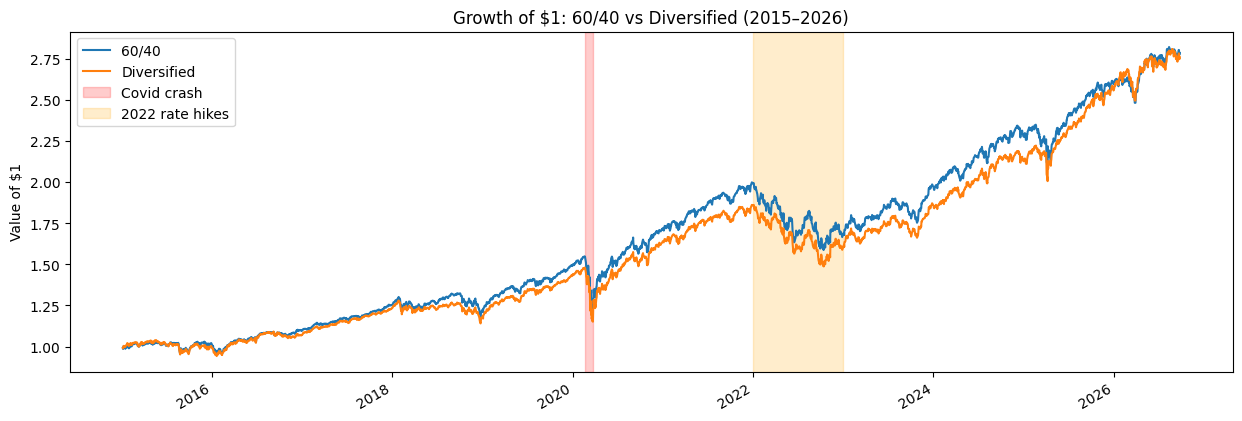

In [100]:
import matplotlib.pyplot as plt

port_wealth = (1 + portfolios).cumprod()

ax = port_wealth.plot(figsize=(15, 5))
ax.axvspan('2020-02-19', '2020-03-23', alpha=0.2, color='red', label='Covid crash')
ax.axvspan('2022-01-01', '2022-12-31', alpha=0.2, color='orange', label='2022 rate hikes')

ax.set_title('Growth of $1: 60/40 vs Diversified (2015–2026)')
ax.set_ylabel('Value of $1')
ax.set_xlabel('')
ax.legend()
plt.show()

The two lines stay close until about 2018, when 60/40 starts pulling ahead. They come back together during the Covid crash, since both fell by about the same percentage, then separate again during the strong stock recovery. In 2022, Diversified fell a little less and closed some of the gap. 60/40 pulled ahead again from 2023 to 2025, but Diversified caught up near the end. Both ended almost tied, with 1 dollar growing to about 2.79 in 60/40 and 2.76 in Diversified.

Plotting each portfolio's drawdown, meaning how far below its last high it was on each day. This shows how deep each drop went and how long it took to recover, which the growth chart doesn't show clearly.

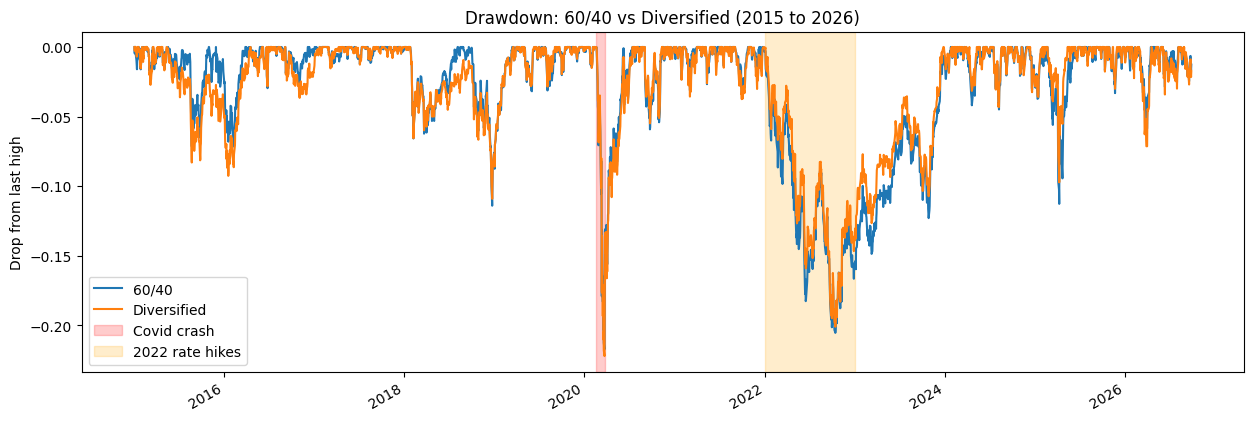

In [101]:
port_drawdown = port_wealth / port_wealth.cummax() - 1

ax = port_drawdown.plot(figsize=(15, 5))
ax.axvspan('2020-02-19', '2020-03-23', alpha=0.2, color='red', label='Covid crash')
ax.axvspan('2022-01-01', '2022-12-31', alpha=0.2, color='orange', label='2022 rate hikes')

ax.set_title('Drawdown: 60/40 vs Diversified (2015 to 2026)')
ax.set_ylabel('Drop from last high')
ax.set_xlabel('')
ax.legend()
plt.show()

Covid was the deepest drop for both portfolios (about -22%), but it was also the shortest, with both recovering within a few months. 2022 was almost as deep (about -20%) but lasted much longer, and neither portfolio got back to its old high until early 2024.

Before 2022, Diversified usually had slightly deeper drops than 60/40. From 2022 until late 2025, that flipped, and Diversified usually had shallower drops. Once rising rates hurt both stocks and bonds in 2022, the extra mix of gold and cash helped. In 2026, Diversified fell behind again, likely because gold had its worst drop of the period in July 2026. So neither portfolio held up better the whole time, and which one did depended on what the market was going through.

## Conclusion: Is the 60/40 portfolio still enough?

Over the full period, the two portfolios ended almost tied. 1 dollar grew to about 2.79 in 60/40 and 2.76 in Diversified, with nearly the same Sharpe ratio (0.657 vs 0.664) and max drawdown (-21.7% vs -22.2%).

The difference showed up in specific periods. 60/40 held up slightly better during the Covid crash, when bonds still cushioned stocks. In 2022, when stocks and bonds fell together, Diversified lost less (-13.9% vs -15.6%) thanks to gold and cash. That advantage lasted until late 2025, but in 2026 gold's drop pulled Diversified back behind.

So 60/40 is still a solid choice, but it depends on bonds protecting against stock drops. When that breaks down, as it did in 2022, spreading money across more assets can help. Neither portfolio came out ahead in every period, so diversifying didn't beat 60/40 overall, but it did change when and how the losses happened.